# User Satisfaction Analysis

### Installing Required Library

In [1]:
pip install pyodbc sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sqlalchemy import create_engine

Loads libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), linear regression (scikit-learn), and database connection (SQLAlchemy).

### Function: load_and_merge_data()

In [3]:
def load_and_merge_data():
    try:
        # Load pre-processed data
        engagement = pd.read_csv(r'dataset\engagement_metrics.csv')
        experience = pd.read_csv(r'dataset\experience_metrics.csv')
        
        # Merge datasets
        satisfaction_df = pd.merge(
            engagement[['MSISDN_Number', 'total_data', 'session_frequency']],
            experience[['MSISDN_Number', 'avg_rtt', 'avg_throughput']],
            on='MSISDN_Number'
        )
        return satisfaction_df
    except Exception as e:
        print(f"Error loading/merging data: {str(e)}")
        return None

### Insights

* Reads two separate CSV files — one with user engagement data, the other with experience data.
* Merges the two datasets on the user ID (MSISDN/Number) and returns the combined DataFrame.
* If anything goes wrong (like file missing or wrong column), it prints the error and returns nothing.

### Function: analyze_satisfaction(df)

In [4]:
def analyze_satisfaction(df):
    try:
        # Calculate satisfaction score
        df['satisfaction_score'] = (
            0.4 * (df['total_data'] / df['total_data'].max()) +
            0.3 * (1 - df['avg_rtt'] / df['avg_rtt'].max()) +
            0.3 * (df['avg_throughput'] / df['avg_throughput'].max())
        )

        # Regression Analysis
        X = df[['total_data', 'avg_rtt', 'avg_throughput']]
        y = df['satisfaction_score']
        model = LinearRegression().fit(X, y)
        print(f"Model R²: {model.score(X, y):.2f}")

        # Visualization
        plt.figure(figsize=(10, 6))
        sns.histplot(df['satisfaction_score'], bins=30, kde=True)
        plt.title('Distribution of User Satisfaction Scores')
        plt.show()

        return df
    except Exception as e:
        print(f"Error in satisfaction analysis: {str(e)}")
        return None

### Insights

* Calculates a custom satisfaction score: High data usage → more satisfaction (40%), Lower RTT → better experience (30%), & Higher throughput → better performance (30%).
* Runs linear regression to understand how well total_data, avg_rtt, and avg_throughput predict the satisfaction score.
* Plots a histogram of satisfaction scores to see how they’re distributed.

### Function: save_to_database(df, table_name)

In [5]:
def save_to_database(df, table_name):
    try:
        server = 'ANIKET\\SQLEXPRESS'
        database = 'telecom_analytics'
        connection_url = (
            f"mssql+pyodbc://{server}/{database}"
            "?driver=ODBC+Driver+17+for+SQL+Server"
            "&trusted_connection=yes"
        )
        engine = create_engine(connection_url)
        
        df.columns = df.columns.str.replace('[^a-zA-Z0-9_]', '_', regex=True)
        df.to_sql(table_name, engine, if_exists='replace', index=False)
        print(f"Data saved to SQL table: {table_name}")
        engine.dispose()
    except Exception as e:
        print(f"Error saving to database: {str(e)}")

### Insights

* Connects to SQL Server database using SQLAlchemy and pyodbc.
* Cleans column names (for SQL compatibility) and saves the DataFrame to a new or replaced SQL table.
* Catches and prints connection or writing errors.

### Main Execution

Model R²: 1.00


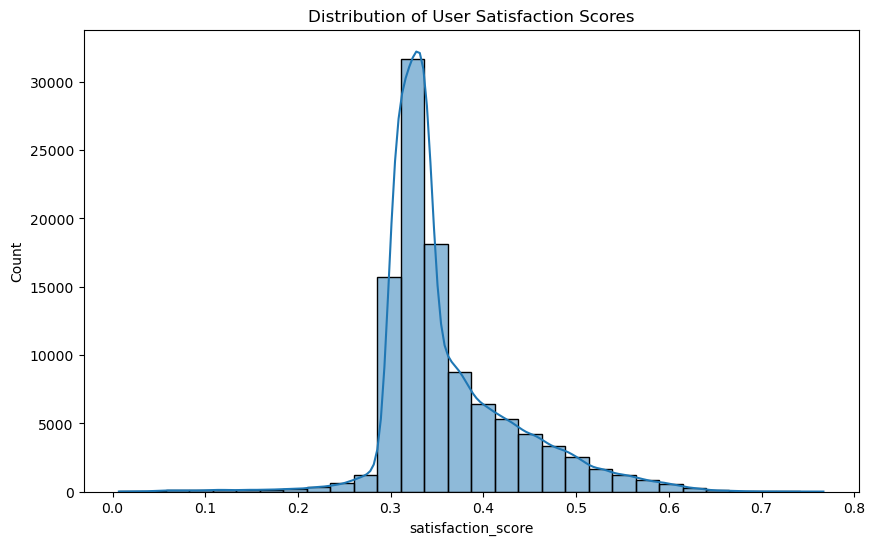

Data saved to SQL table: user_satisfaction_metrics

Top 10 Satisfied Users:
       MSISDN_Number  satisfaction_score
55648   3.366471e+10            0.766739
31556   3.365873e+10            0.753335
67967   3.366874e+10            0.738504
85325   3.369925e+10            0.737807
36068   3.365973e+10            0.734397
68985   3.366911e+10            0.721557
93256   3.376172e+10            0.717845
32041   3.365883e+10            0.717242
70600   3.366969e+10            0.714831
35299   3.365955e+10            0.710939

Bottom 10 Users:
        MSISDN_Number  satisfaction_score
102056   3.378314e+10            0.006872
68627    3.366900e+10            0.012577
99984    3.377680e+10            0.014440
6959     3.361598e+10            0.015422
75694    3.367912e+10            0.017442
51049    3.366341e+10            0.021355
67235    3.366851e+10            0.025288
64749    3.366768e+10            0.025810
45320    3.366199e+10            0.030075
7137     3.361631e+10            0.

In [7]:
if __name__ == "__main__":
    satisfaction_df = load_and_merge_data()
    if satisfaction_df is not None:
        satisfaction_df = analyze_satisfaction(satisfaction_df)
        if satisfaction_df is not None:
            save_to_database(satisfaction_df, 'user_satisfaction_metrics')
             # Save CSV
            satisfaction_df.to_csv(r'dataset\user_satisfaction_metrics.csv', index=False)

            print("\nTop 10 Satisfied Users:")
            print(satisfaction_df.nlargest(10, 'satisfaction_score')[['MSISDN_Number', 'satisfaction_score']])

            print("\nBottom 10 Users:")
            print(satisfaction_df.nsmallest(10, 'satisfaction_score')[['MSISDN_Number', 'satisfaction_score']])